In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import inspeqtor.experimental as sq
import seaborn as sns
import scienceplots as scienceplots
import gen_data as ml

/Users/porametpathumsoot/University/PhD/papers/paper_2_code_v2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
colors = {
    "blue": "#6366f1",
    "red": "#f43f5e",
    "gray": "#4b5563"
}

In [3]:
TROTTER_STEPS = 10_000
NOISE_STR = 0.01
DETUNE = 0.001
data_model = ml.get_data_model(
    noise_str=NOISE_STR, detune=DETUNE, trotter_steps=TROTTER_STEPS
)
control_sequence = data_model.control_sequence
qubit_info = data_model.qubit_information
_, l2a_fn = sq.control.get_param_array_converter(control_sequence)

signal_fn = sq.physics.signal_func_v5(
    get_envelope=sq.control.get_envelope_transformer(control_sequence=control_sequence),
    drive_frequency=qubit_info.frequency,
    dt=data_model.dt,
)

key = jax.random.key(0)

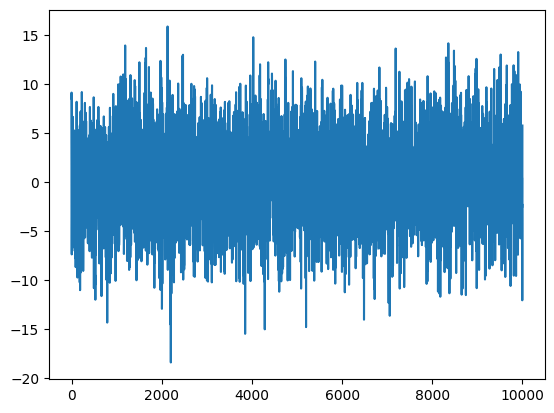

In [4]:
T = control_sequence.total_dt * data_model.dt  # Time(1 / T = dw)
nt = TROTTER_STEPS  # Num.of Discretized Time
F = 1 / T * nt / 2  # Frequency.(Hz)
nw = int(nt / 2)  # Num of Discretized Freq.

# Generation of Input Data(Stationary)
t = jnp.linspace(0, T, nt)
dw = F / nw
w = jnp.linspace(0, F, nw)
spectrum = ml.get_PSD_v1()(w)
noise_fn = ml.make_noise_fn(spectrum, w, nt, dw)
key, subkey = jax.random.split(key)
sample = noise_fn(subkey)
plt.plot(sample)

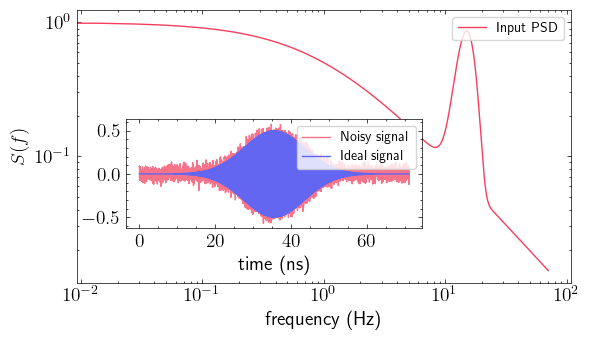

In [5]:
with plt.style.context("science"):
    fontsize = 14
    fig, ax = plt.subplots(figsize=(6, 3.5))

    ax.loglog(np.array(w), np.array(spectrum), color=colors["red"], label="Input PSD")
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("$S(f)$")
    params = jnp.array([2 * jnp.pi])

    noisy_signal = signal_fn(params, t) + NOISE_STR * noise_fn(subkey)

    inset_ax = ax.inset_axes((0.1, 0.20, 0.6, 0.4))
    inset_ax.plot(
        t, noisy_signal, color=colors["red"], alpha=0.73, label="Noisy signal"
    )
    inset_ax.plot(t, signal_fn(params, t), color=colors["blue"], label="Ideal signal")
    inset_ax.set_xlabel("time (ns)")
    sq.visualization.set_fontsize(ax, fontsize)
    sq.visualization.set_fontsize(inset_ax, fontsize)

    ax.legend(loc="upper right", frameon=True)
    inset_ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
fig.savefig("fig_psd_profile_and_signal.pdf")

In [6]:
def simulate(
    key, params=jnp.array([jnp.pi / 3]), noise_str=0.01, N_UNITARY_SAMPLES=1000
):
    SHOTS = 10000
    SAMPLE_SIZE = 1000

    y0 = jnp.eye(2, dtype=jnp.complex128)

    noisy_signal_fn = ml.make_noisy_signal_fn(
        signal_fn, t, spectrum, w, noise_str=noise_str, dw=dw
    )
    hamiltonian = ml.make_noisy_hamiltonian(
        t, qubit_info, noisy_signal_fn, detune=DETUNE
    )
    stochastic_solver = ml.make_final_returned_whitebox_fn(
        ml.make_stochastic_trotterization_solver(hamiltonian, t, y0)
    )

    unitaries = ml.make_prepare_unitary_ensemble(stochastic_solver, N_UNITARY_SAMPLES)(
        key, params
    )
    initial_state = sq.data.State.from_label("1", dm=True)
    observable = sq.data.Operator.from_label("Z")

    intermediate_expval = sq.physics.calculate_exp(
        unitaries, operator=observable, density_matrix=initial_state
    )
    probs = sq.utils.expectation_value_to_prob_plus(intermediate_expval)

    key, subkey = jax.random.split(key)
    sim = jax.vmap(ml.simulate_the_shot, in_axes=(0, None))(
        jax.random.split(subkey, int(SAMPLE_SIZE * SHOTS)), probs
    )

    stochastic_expval_sample = sim.reshape(SAMPLE_SIZE, SHOTS).mean(1)

    theoretical_stochastic_variance = sq.utils.variance_of_observable(
        intermediate_expval.mean(), SHOTS
    )
    print(f"Theoreitical variance: {theoretical_stochastic_variance:.5f} ")
    print(f"The distribution of Probability: {probs.mean():.5f} {probs.std():.5f}")
    print(
        f"The finite-shot expectation value and the variance: {stochastic_expval_sample.mean():3f} {stochastic_expval_sample.var():3f}",
    )
    return intermediate_expval, stochastic_expval_sample


In [7]:
key, subkey = jax.random.split(key)
deterministic_intermediate_expval, deterministic_expval_sample = simulate(
    subkey, params, noise_str=0.0
)

Theoreitical variance: 0.00000 
The distribution of Probability: 0.00505 0.00000
The finite-shot expectation value and the variance: -0.989870 0.000002


In [8]:
key, subkey = jax.random.split(key)
weak_stoc_intermediate_expval, weak_stoc_expval_sample = simulate(
    subkey, params, noise_str=0.01
)

Theoreitical variance: 0.00000 
The distribution of Probability: 0.00554 0.00220
The finite-shot expectation value and the variance: -0.988975 0.000002


In [9]:
key, subkey = jax.random.split(key)
strong_stoc_intermediate_expval, strong_stoc_expval_sample = simulate(
    subkey, params, noise_str=0.05
)

Theoreitical variance: 0.00001 
The distribution of Probability: 0.01487 0.01328
The finite-shot expectation value and the variance: -0.970311 0.000006


In [10]:
from matplotlib.ticker import MaxNLocator, MultipleLocator

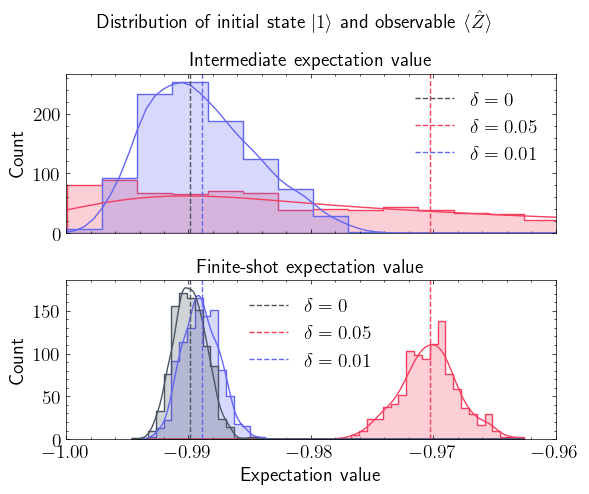

In [12]:
stochastic_weak_text = r"$\delta = 0.01$"
stochastic_strong_text = r"$\delta = 0.05$"

with plt.style.context("science"):
    fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
    axes = sq.visualization.assert_list_of_axes(axes)

    sns.histplot(
        {
            stochastic_weak_text: weak_stoc_intermediate_expval,
            stochastic_strong_text: strong_stoc_intermediate_expval,
        },
        element="step",
        kde=True,
        bins=50,
        ax=axes[0],
        fill=True,
        palette={
            stochastic_weak_text: colors["blue"],
            stochastic_strong_text: colors["red"],
        },
    )

    sns.histplot(
        {
            "deterministic": deterministic_expval_sample,
            stochastic_weak_text: weak_stoc_expval_sample,
            stochastic_strong_text: strong_stoc_expval_sample,
        },
        element="step",
        kde=True,
        ax=axes[1],
        bins=50,
        palette={
            "deterministic": colors["gray"],
            stochastic_weak_text: colors["blue"],
            stochastic_strong_text: colors["red"],
        },
    )

    axes[0].set_title(r"Intermediate expectation value")
    axes[1].set_title(r"Finite-shot expectation value")

    axes[0].set_xlim(-1, -0.96)
    axes[1].set_xlim(-1, -0.96)
    axes[1].set_xlabel("Expectation value")
    # axes[1].set_xticks([-0.99, -0.98, -0.97])
    axes[1].xaxis.set_major_locator(MaxNLocator(nbins=4))
    axes[1].xaxis.set_major_locator(MultipleLocator(0.01))  # Tick every 0.01

    for ax in axes:
        ax.axvline(
            deterministic_intermediate_expval.mean().item(),
            label=r"$\delta = 0$",
            color=colors["gray"],
            linestyle="dashed",
        )

        ax.axvline(
            strong_stoc_intermediate_expval.mean().item(),
            label=stochastic_strong_text,
            color=colors["red"],
            linestyle="dashed",
        )

        ax.axvline(
            weak_stoc_intermediate_expval.mean().item(),
            label=stochastic_weak_text,
            color=colors["blue"],
            linestyle="dashed",
        )
        sq.visualization.set_fontsize(ax, fontsize)
        # ax.legend()

    # ax.legend()

    # fig.suptitle(r"Distribution of $\langle \hat{Z} \rangle_{|1\rangle}$")
    fig.suptitle(
        r"Distribution of initial state $|1\rangle$ and observable $\langle \hat{Z} \rangle$",
        fontsize=fontsize,
    )
    fig.tight_layout()
fig.savefig("fig_shift.pdf")